K mean algo

In [2]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np
%matplotlib inline

In [3]:
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=23)


In [4]:
y

array([0, 0, 1, 2, 2, 0, 2, 1, 2, 1, 1, 0, 1, 2, 2, 0, 1, 2, 0, 1, 0, 1,
       2, 1, 0, 1, 0, 2, 2, 0, 2, 0, 0, 0, 1, 0, 0, 2, 1, 2, 1, 0, 2, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 1, 2, 1, 2, 1, 0, 0, 1, 2, 0,
       2, 2, 2, 1, 2, 1, 1, 0, 0, 2, 0, 0, 2, 2, 2, 2, 1, 1, 0, 1, 0, 0,
       0, 2, 0, 0, 2, 2, 1, 2, 2, 1, 1, 1])

In [5]:
X.shape

(100, 2)

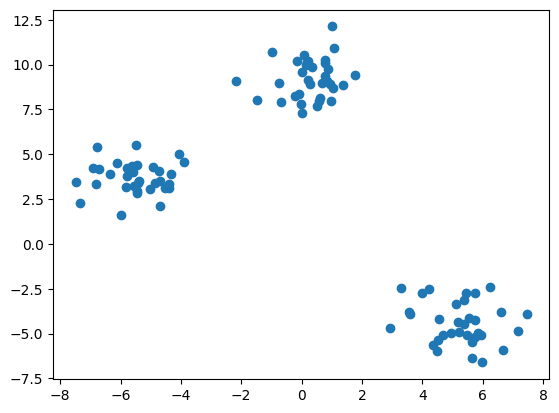

In [6]:
plt.scatter(X[:,0],X[:,1])

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test ,y_train , y_test = train_test_split(X,y, test_size = 30, random_state = 42)

In [8]:
from sklearn.cluster import KMeans

In [9]:
# Manual process
#  Elobow meathod (Within-Cluster Sum of Squares)
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters= k, init = 'k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [10]:
wcss #itis decreasing it mean it is good

[3756.4495480843407,
 851.9661073755742,
 140.71842125902225,
 112.95673069628472,
 112.22968964715196,
 86.82389165361488,
 67.39042628093935,
 61.074954715548756,
 58.6646951582326,
 48.41407821188776]

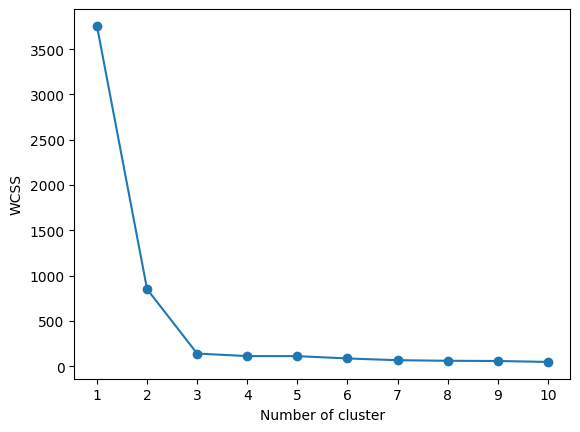

In [11]:
#  now we make elbow curve 
plt.plot(range(1,11),wcss,marker = 'o')
plt.xticks(range(1,11))
plt.xlabel('Number of cluster')
plt.ylabel("WCSS")
plt.show()

In [12]:
# creating model
kmeans=KMeans(n_clusters=3,init = 'k-means++')
print(kmeans)

KMeans(n_clusters=3)


In [13]:
y_label = kmeans.fit_predict(X_train)
print(y_label)
#  these 0,1,2 are showing cluster 0 -> first cluster like this

[1 0 0 2 2 1 2 1 1 0 0 0 0 2 2 0 2 0 1 2 1 2 2 0 2 2 2 2 1 2 0 0 0 0 0 2 1
 2 1 0 2 1 0 0 0 2 2 1 0 2 0 1 2 1 1 2 0 0 0 1 1 1 1 0 1 0 0 2 2 1]


In [14]:
y_test_label = kmeans.predict(X_test)
print(y_test_label)

[0 1 2 1 1 2 2 2 0 1 1 2 1 1 1 2 1 1 0 1 2 1 1 2 0 1 0 2 0 0]


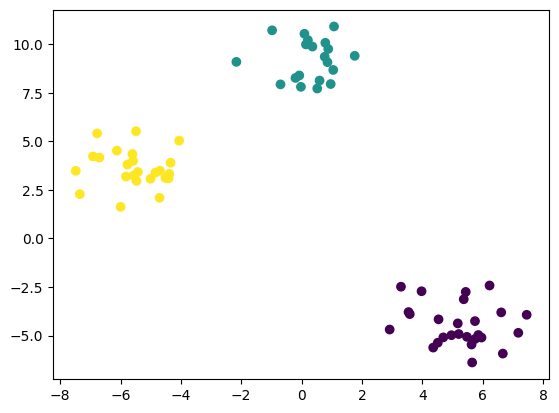

In [15]:
plt.scatter(X_train[:,0],X_train[:,1], c= y_label)

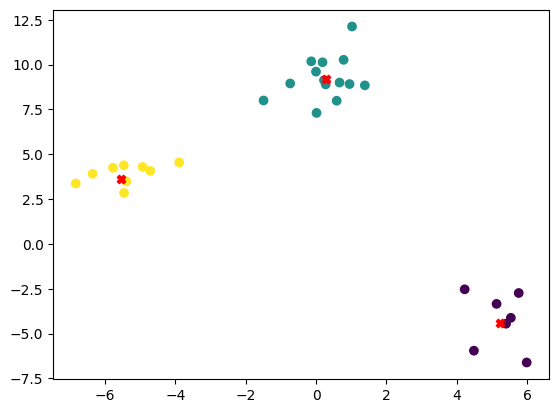

In [16]:
plt.scatter(X_test[:, 0],X_test[:, 1],c = y_test_label)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', c='red')
# this line show centroid in res color

In [17]:
# Atuomated meathod to find cluster/k
from kneed import KneeLocator

In [18]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [19]:
# performance metrix
# silhoutte score

from sklearn.metrics import silhouette_score



In [20]:
silhouette_coefficient = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++",)
    kmeans.fit(X_train)
    score = silhouette_score(X_train,kmeans.labels_)
    silhouette_coefficient.append(score)

In [21]:
silhouette_coefficient

[0.7206578032219199,
 0.8095998586756642,
 0.6944258341874825,
 0.539348089031335,
 0.5095864936714836,
 0.40753945478043624,
 0.3869205997566177,
 0.3550359573128638,
 0.38525157326542975]

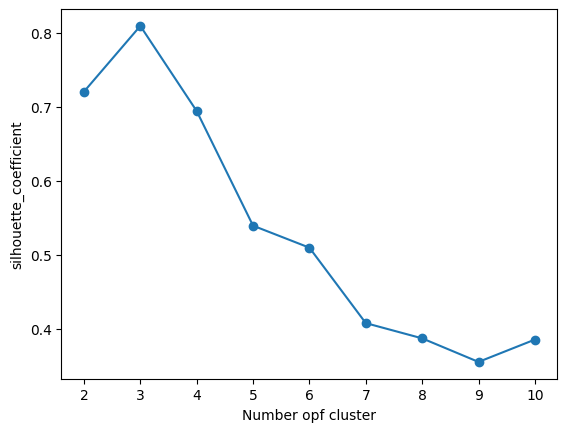

In [27]:
plt.plot(range(2,11),silhouette_coefficient,marker = 'o')
plt.xticks(range(2,11))
plt.xlabel("Number opf cluster")
plt.ylabel("silhouette_coefficient")
plt.show()

In [23]:
print("hellow")

hellow
